#Experiment with Non-preprocessing dataset

#Import Library

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import joblib  # For saving/loading model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier  # Changed to Random Forest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm
import random
from collections import Counter

#Mount Drive

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Define dataset path

In [ ]:
# Define dataset path
dataset_path = "/content/drive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_2"
own_dataset_path = "/content/drive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_2/OwnDataset"

# Define classes

In [ ]:
categories = ["Ripe", "Unripe", "Semiripe", "Overripe-Rotten"]

#Function to extract Color Histogram features

In [ ]:
def extract_color_histogram(image, bins=(8, 8, 8)):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)  # Convert to HSV color space
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)  # Normalize histogram
    return hist.flatten()

#Count Images and Image Shapes

In [ ]:
# Count images in each folder and calculate proportions
image_counts = {}
total_images = 0

for label in categories:
    directory = os.path.join(dataset_path, label)
    if os.path.isdir(directory):
        num_images = len([f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])
        image_counts[label] = num_images
        total_images += num_images

# Print image counts
print("\nImage Counts in Dataset:")
for label, count in image_counts.items():
    proportion = (count / total_images) * 100 if total_images > 0 else 0
    print(f"{label}: {count} images ({proportion:.2f}%)")


Image Counts in Dataset:
Ripe: 350 images (25.00%)
Unripe: 350 images (25.00%)
Semiripe: 350 images (25.00%)
Overripe-Rotten: 350 images (25.00%)


In [ ]:
# Count image shapes
image_shapes = []
for label in image_counts.keys():
    directory = os.path.join(dataset_path, label)
    for f in os.listdir(directory):
        image_path = os.path.join(directory, f)
        img = cv2.imread(image_path)
        if img is not None:
            image_shapes.append(img.shape)

shape_counts = Counter(image_shapes)
print("\nImage Shape Counts:")
for shape, count in shape_counts.items():
    print(f"{shape}: {count} images")


Image Shape Counts:
(224, 224, 3): 1400 images


#Load Dataset

In [ ]:
# Function to load dataset (flexible for both training & testing)
def load_dataset(base_path):
    data = []
    labels = []
    image_paths = []

    for category in categories:
        folder_path = os.path.join(base_path, category)
        label = category

        if not os.path.exists(folder_path):
            print(f"Folder not found: {folder_path}")
            continue

        for img_name in tqdm(os.listdir(folder_path), desc=f"Loading {category}"):
            img_path = os.path.join(folder_path, img_name)

            # Read image in RGB format
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))  # Keep uniform size

            # Extract Color Histogram Features
            features = extract_color_histogram(img)

            data.append(features)
            labels.append(label)
            image_paths.append(img_path)  # Store image path for visualization

    data = np.array(data, dtype=np.float32)
    labels = np.array(labels)

    return data, labels, image_paths

In [ ]:
# Load Training Dataset
print("\nLoading Training Dataset...")
data, labels, image_paths = load_dataset(dataset_path)


Loading Training Dataset...


Loading Overripe-Rotten: 100%|██████████| 350/350 [00:02<00:00, 152.78it/s]


In [ ]:
# Encode labels (Convert category names to numerical labels)
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

In [ ]:
print("\nChecking Label Encoding...")
label_df = pd.DataFrame({"Original Label": labels, "Encoded Label": encoded_labels})
print(label_df.head(10))  # Display first 10 label mappings

# Print unique label encoding mapping
print("\nLabel Encoding Mapping:")
for label, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{label} -> {encoded}")


Checking Label Encoding...
  Original Label  Encoded Label
0           Ripe              1
1           Ripe              1
2           Ripe              1
3           Ripe              1
4           Ripe              1
5           Ripe              1
6           Ripe              1
7           Ripe              1
8           Ripe              1
9           Ripe              1

Label Encoding Mapping:
Overripe-Rotten -> 0
Ripe -> 1
Semiripe -> 2
Unripe -> 3


###Display the Images

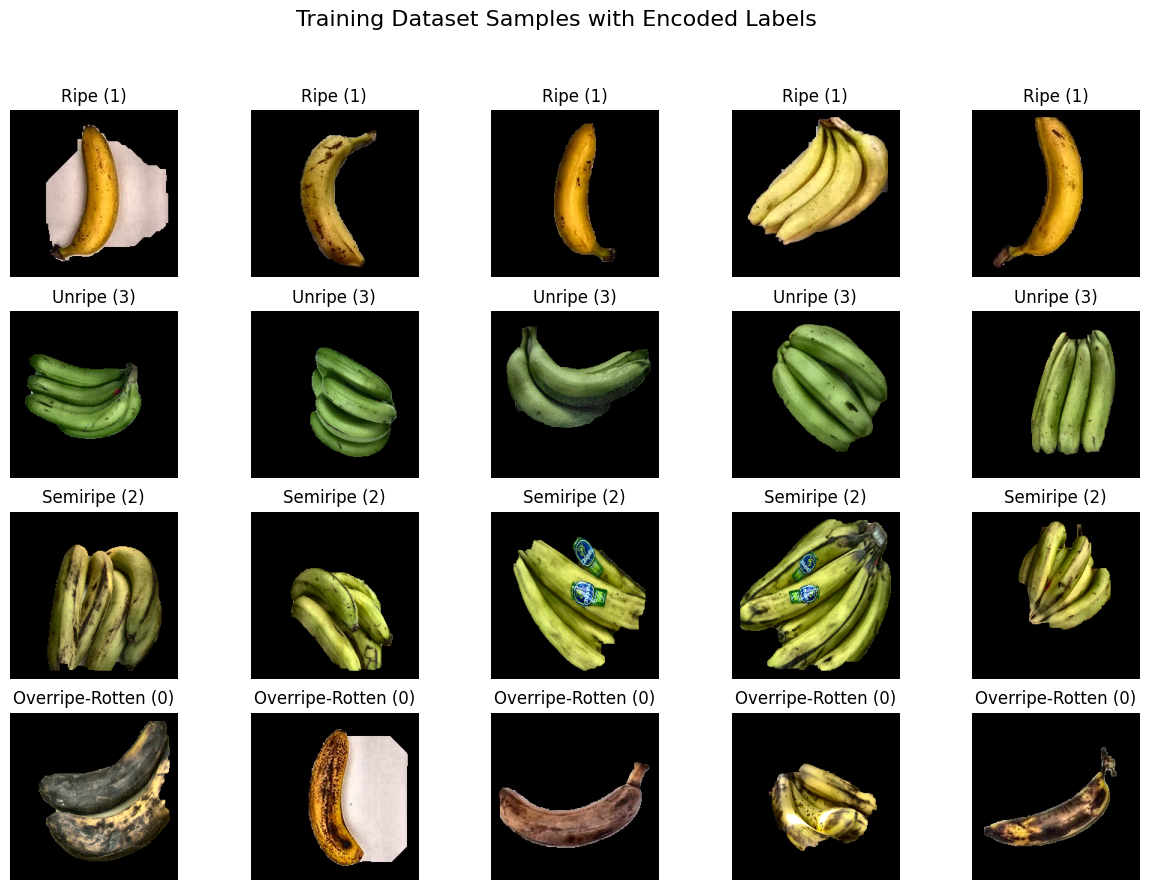

In [ ]:
#  VISUALIZE 5 IMAGES FROM EACH CLASS (WITH ENCODED LABELS)
def visualize_class_samples(base_path, label_encoder, title="Sample Images from Each Class"):
    fig, axes = plt.subplots(len(categories), 5, figsize=(15, 10))

    for i, category in enumerate(categories):
        folder_path = os.path.join(base_path, category)
        if not os.path.exists(folder_path):
            continue

        # Get encoded label for this category
        encoded_label = label_encoder.transform([category])[0]

        images = random.sample(os.listdir(folder_path), min(5, len(os.listdir(folder_path))))  # Select up to 5 images

        for j, img_name in enumerate(images):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Display the image with the original and encoded label
            axes[i, j].imshow(img)
            axes[i, j].axis("off")
            axes[i, j].set_title(f"{category} ({encoded_label})")

    plt.suptitle(title, fontsize=16)
    plt.show()

# Call the function with the label encoder
visualize_class_samples(dataset_path, label_encoder, "Training Dataset Samples with Encoded Labels")


#Split Dataset (80:10)

In [ ]:
# Split Dataset (80:10:10)
X_train, X_test, y_train, y_test, img_train_paths, img_test_paths = train_test_split(
    data, encoded_labels, image_paths, test_size=0.2, random_state=42, stratify=encoded_labels)

In [ ]:
# Print dataset sizes
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 1120
Test set size: 280


In [ ]:
# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Random Forest Model

In [ ]:
# Train an Random Forest Model
print("\nTraining Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


Training Random Forest Model...


RandomForestClassifier(random_state=42)

##Save the model

In [ ]:
# Save the trained model & scaler
model_save_path = "/content/drive/MyDrive/TCV BANANA/RF_EP2.pkl"
scaler_save_path = "/content/drive/MyDrive/TCV BANANA/scalerEP2.pkl"
joblib.dump(rf_model, model_save_path)
joblib.dump(scaler, scaler_save_path)
print(f"\nModel saved at: {model_save_path}")


Model saved at: /content/drive/MyDrive/TCV BANANA/RF_EP2.pkl


##Evaluation

In [ ]:
# Predictions on test set
y_pred = rf_model.predict(X_test)

In [ ]:
# Model Evaluation
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")


Classification Report (Test Data):
                 precision    recall  f1-score   support

Overripe-Rotten       0.93      0.94      0.94        70
           Ripe       0.94      0.87      0.90        70
       Semiripe       0.91      0.97      0.94        70
         Unripe       1.00      0.99      0.99        70

       accuracy                           0.94       280
      macro avg       0.94      0.94      0.94       280
   weighted avg       0.94      0.94      0.94       280


Confusion Matrix:
[[66  2  2  0]
 [ 4 61  5  0]
 [ 0  2 68  0]
 [ 1  0  0 69]]

Model Accuracy: 94.29%


In [ ]:
# ---- VISUALIZE 5 RANDOM TEST IMAGES WITH PREDICTIONS ----
def visualize_predictions(image_paths, X_data, y_true, y_pred, title="Prediction Results"):
    num_samples = 5
    indices = random.sample(range(len(X_data)), num_samples)  # Randomly select test indices

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

    for i, idx in enumerate(indices):
        img_path = image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        true_label = label_encoder.inverse_transform([y_true[idx]])[0]
        predicted_label = label_encoder.inverse_transform([y_pred[idx]])[0]

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"True: {true_label}\nPred: {predicted_label}")

    plt.suptitle(title, fontsize=14)
    plt.show()

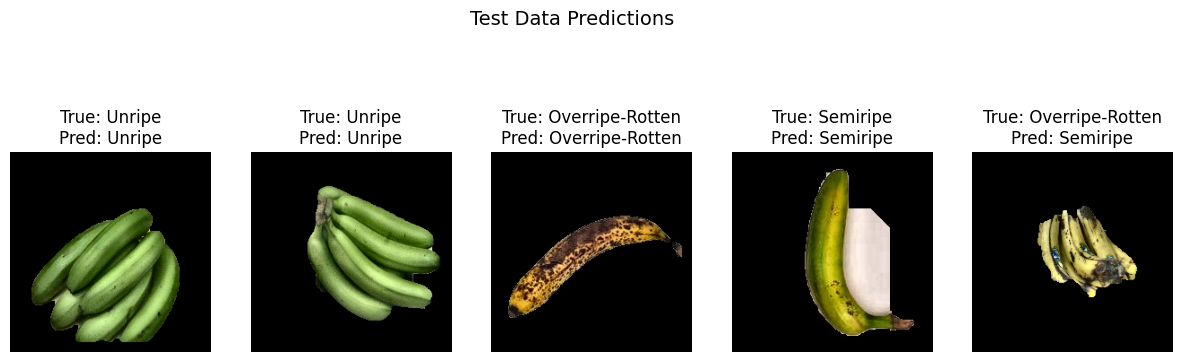

In [ ]:
# Display random test images with their predictions
visualize_predictions(img_test_paths, X_test, y_test, y_pred, "Test Data Predictions")

# Testing with No Preprocessed Dataset (Own)

In [ ]:
# TEST GENERALIZATION ON NEW DATASET
print("\nTesting on Own Dataset...")
own_data, own_labels, own_image_paths = load_dataset(own_dataset_path)


Testing on Own Dataset...


Loading Overripe-Rotten: 100%|██████████| 70/70 [00:48<00:00,  1.43it/s]


In [ ]:
# Encode labels (Use same encoder)
own_encoded_labels = label_encoder.transform(own_labels)

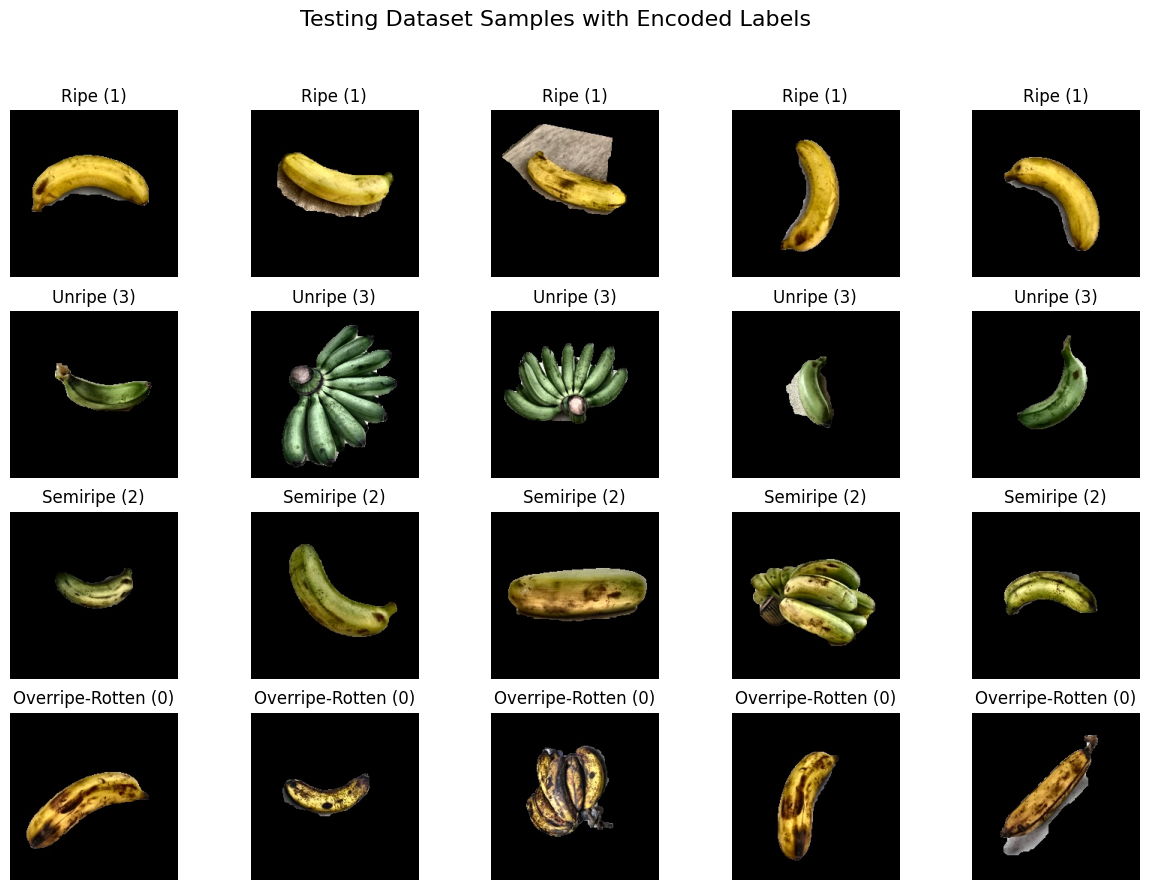

In [ ]:
# Display sample images from each class (Training Data)
visualize_class_samples(own_dataset_path, label_encoder, "Testing Dataset Samples with Encoded Labels")

In [ ]:
# Normalize features (Use same scaler)
own_data = scaler.transform(own_data)

In [ ]:
# Load trained model (For Safety)
rf_model = joblib.load(model_save_path)

In [ ]:
# Predictions on new dataset
own_pred = rf_model.predict(own_data)

In [ ]:
# Model Evaluation on New Dataset
print("\nClassification Report (Own Dataset):")
print(classification_report(own_encoded_labels, own_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix (Own Dataset):")
print(confusion_matrix(own_encoded_labels, own_pred))

print(f"\nGeneralization Accuracy (Own Dataset): {accuracy_score(own_encoded_labels, own_pred) * 100:.2f}%")


Classification Report (Own Dataset):
                 precision    recall  f1-score   support

Overripe-Rotten       0.88      0.91      0.90        70
           Ripe       0.85      0.94      0.89        70
       Semiripe       0.84      0.66      0.74        70
         Unripe       0.82      0.87      0.85        70

       accuracy                           0.85       280
      macro avg       0.85      0.85      0.84       280
   weighted avg       0.85      0.85      0.84       280


Confusion Matrix (Own Dataset):
[[64  6  0  0]
 [ 2 66  2  0]
 [ 5  6 46 13]
 [ 2  0  7 61]]

Generalization Accuracy (Own Dataset): 84.64%


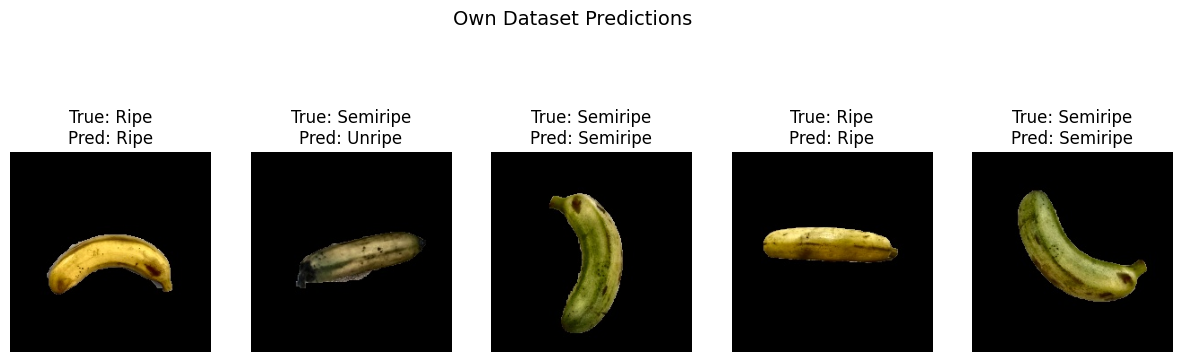

In [ ]:
# Visualize random test images with their predictions (Own Dataset)
visualize_predictions(own_image_paths, own_data, own_encoded_labels, own_pred, "Own Dataset Predictions")